#  House Price Prediction — End-to-End ML Pipeline
**Skills:** Python · Data Analytics · Data Science · Machine Learning · EDA

### Pipeline
1. Load & Inspect Data  2. EDA  3. Feature Engineering
4. Preprocessing  5. Train 6 Models  6. Cross-Validation
7. Visualisations  8. Save Model  9. Predict New Prices

## Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 42
print('✅ All libraries imported!')

✅ All libraries imported!


## Load Data

In [3]:
df = pd.read_csv('house_price_dataset.csv')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Shape: 1,000 rows × 8 columns


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


## Data Overview

In [4]:
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum())
df.describe().round(2)

Square_Footage            int64
Num_Bedrooms              int64
Num_Bathrooms             int64
Year_Built                int64
Lot_Size                float64
Garage_Size               int64
Neighborhood_Quality      int64
House_Price             float64
dtype: object

Missing values:
Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,2815.42,2.99,1.97,1986.55,2.78,1.02,5.62,618861.02
std,1255.51,1.43,0.82,20.63,1.30,0.81,2.89,253568.06
min,503.00,1.00,1.00,1950.00,0.51,0.00,1.00,111626.85
25%,1749.50,2.00,1.00,1969.00,1.67,0.00,3.00,401648.23
50%,2862.50,3.00,2.00,1986.00,2.81,1.00,6.00,628267.29
75%,3849.50,4.00,3.00,2004.25,3.92,2.00,8.00,827141.28
max,4999.00,5.00,3.00,2022.00,4.99,2.00,10.00,1108236.84


## EDA: Target Distribution

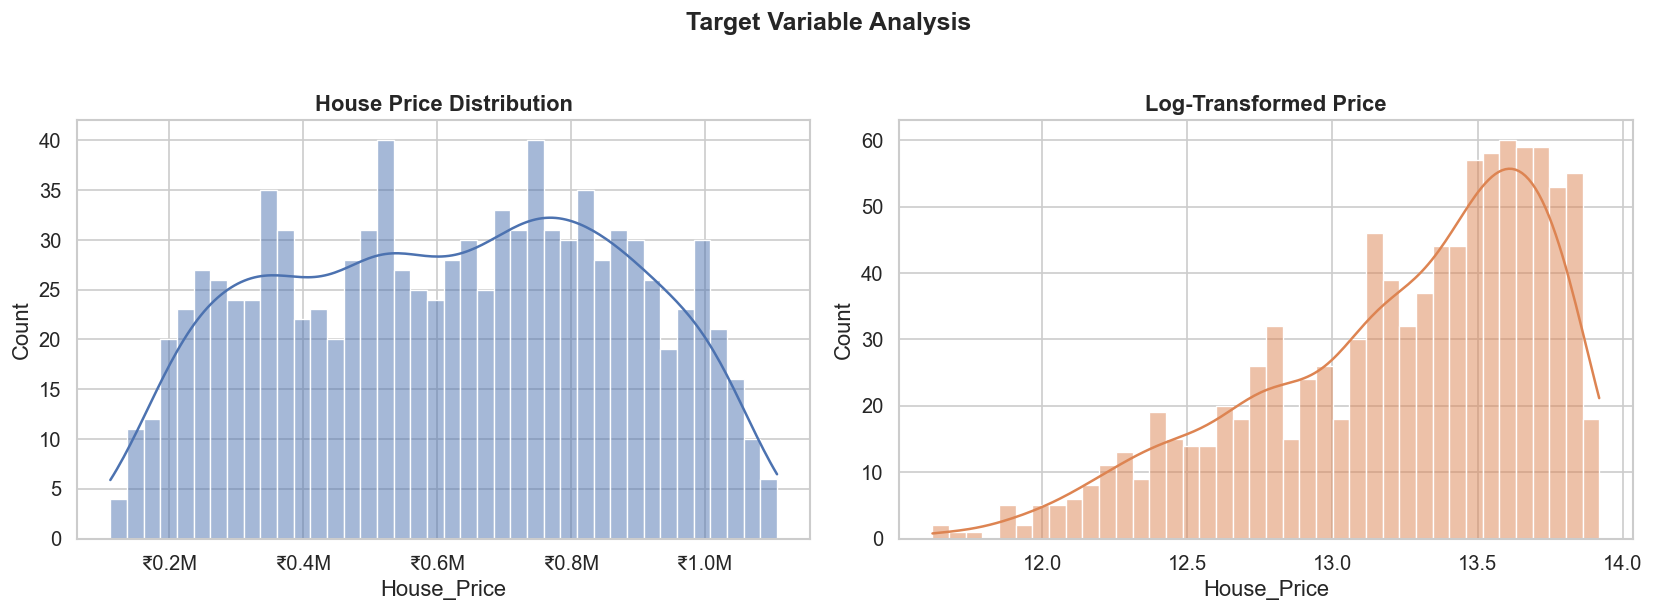

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['House_Price'], kde=True, ax=axes[0], color='#4C72B0', bins=40)
axes[0].set_title('House Price Distribution', fontweight='bold')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))
sns.histplot(np.log1p(df['House_Price']), kde=True, ax=axes[1], color='#DD8452', bins=40)
axes[1].set_title('Log-Transformed Price', fontweight='bold')
plt.suptitle('Target Variable Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('01_target_dist.png', bbox_inches='tight'); plt.show()

## EDA: Correlation Heatmap

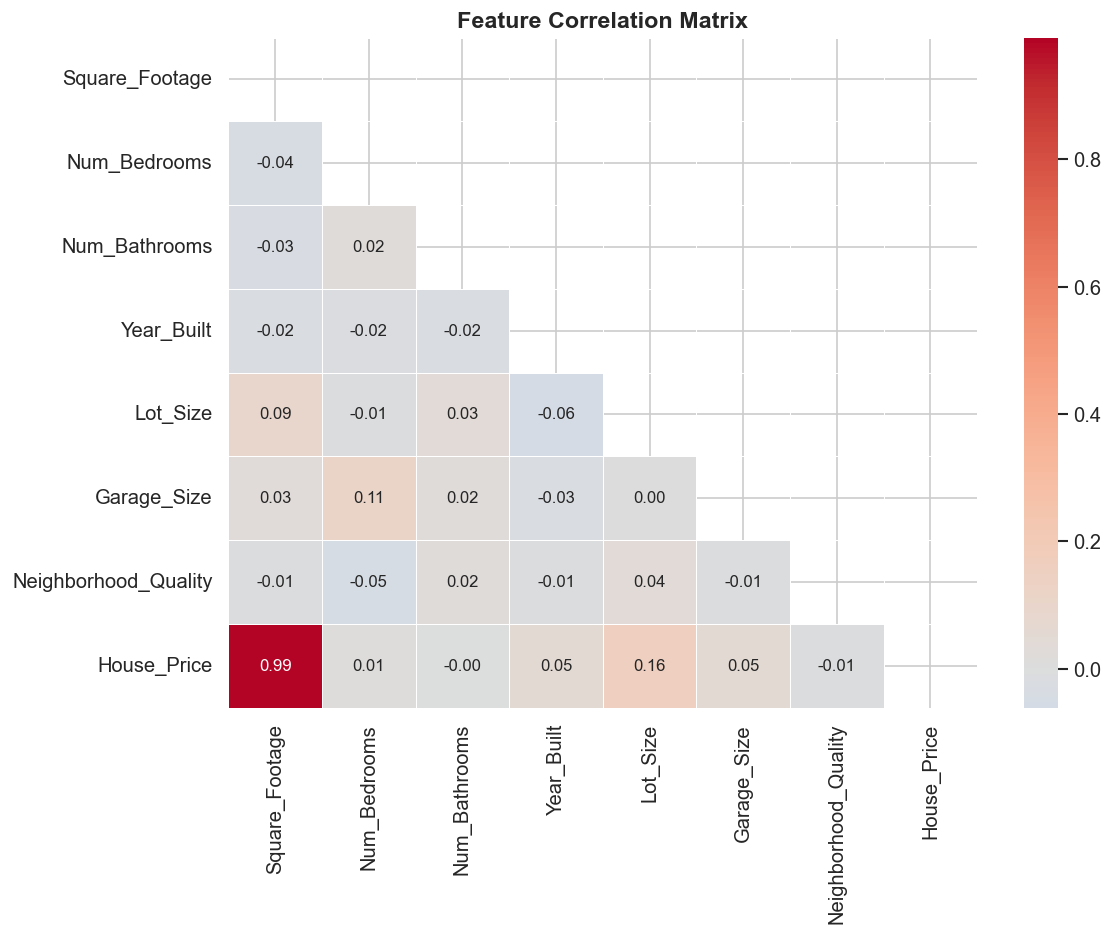


Correlations with House_Price:
House_Price             1.000000
Square_Footage          0.991261
Lot_Size                0.160412
Garage_Size             0.052133
Year_Built              0.051967
Num_Bedrooms            0.014633
Num_Bathrooms          -0.001862
Neighborhood_Quality   -0.007770
Name: House_Price, dtype: float64


In [6]:
fig, ax = plt.subplots(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 10})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('02_correlation.png', bbox_inches='tight'); plt.show()
print('\nCorrelations with House_Price:')
print(corr['House_Price'].sort_values(ascending=False))

## EDA: Scatter Plots

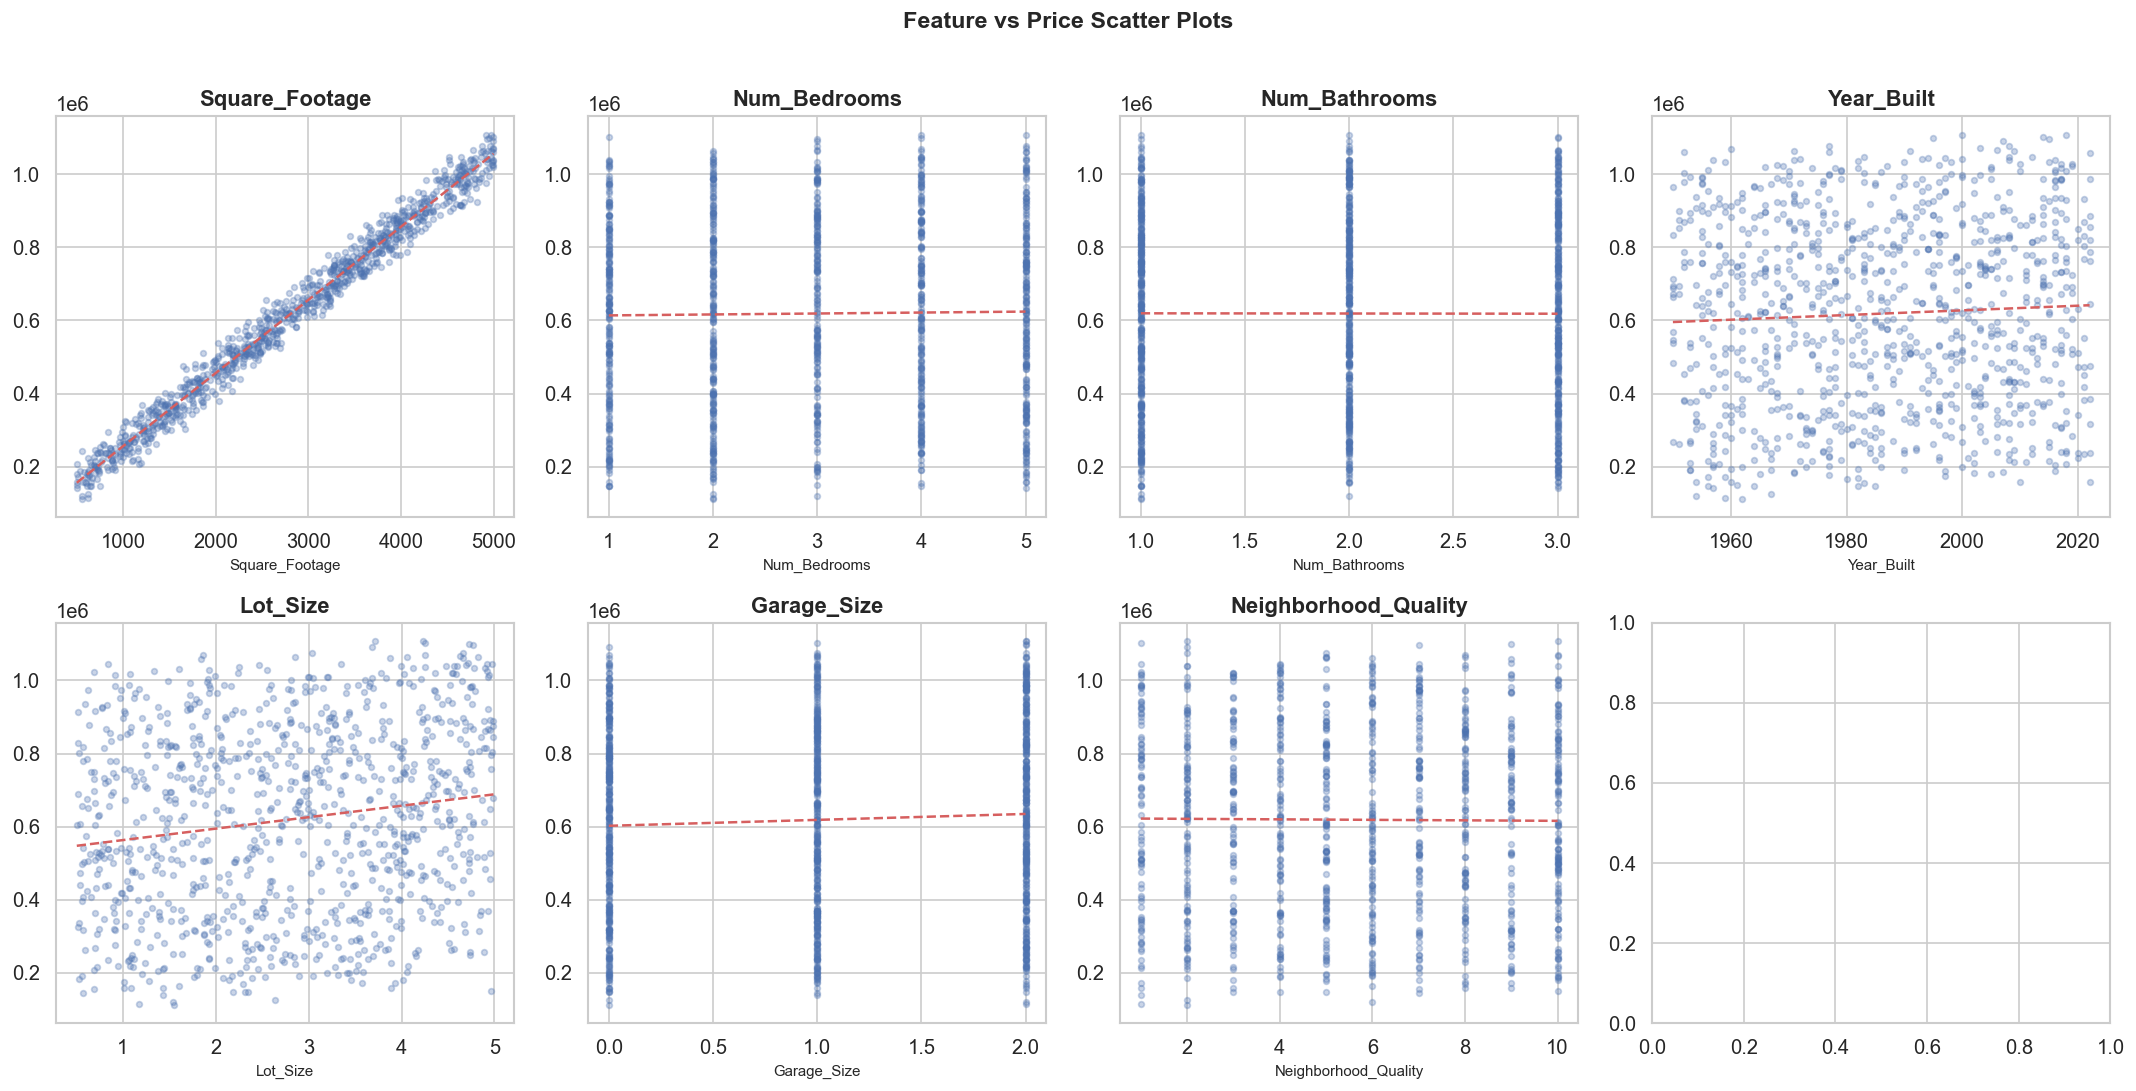

In [7]:
features = [c for c in df.columns if c != 'House_Price']
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
for i, feat in enumerate(features):
    axes[i].scatter(df[feat], df['House_Price'], alpha=0.3, s=12, color='#4C72B0')
    z = np.polyfit(df[feat], df['House_Price'], 1)
    x_l = np.linspace(df[feat].min(), df[feat].max(), 100)
    axes[i].plot(x_l, np.poly1d(z)(x_l), 'r--', linewidth=1.5)
    axes[i].set_xlabel(feat, fontsize=9); axes[i].set_title(feat, fontweight='bold')
plt.suptitle('Feature vs Price Scatter Plots', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.savefig('03_scatter.png', bbox_inches='tight'); plt.show()

## Feature Engineering

In [8]:
df_eng = df.copy()
df_eng['House_Age']      = 2024 - df_eng['Year_Built']
df_eng['Total_Rooms']    = df_eng['Num_Bedrooms'] + df_eng['Num_Bathrooms']
df_eng['Size_x_Quality'] = df_eng['Square_Footage'] * df_eng['Neighborhood_Quality']
df_eng['Has_Garage']     = (df_eng['Garage_Size'] > 0).astype(int)
print(f'Features: {df.shape[1]-1} → {df_eng.shape[1]-1}')
df_eng.head()

Features: 7 → 11


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price,House_Age,Total_Rooms,Size_x_Quality,Has_Garage
0,1360,2,1,1981,0.599637,0,5,2.623829e+05,43,3,6800,0
1,4272,3,3,2016,4.753014,1,6,9.852609e+05,8,6,25632,1
2,3592,1,2,2016,3.634823,0,9,7.779774e+05,8,3,32328,0
3,966,1,2,1977,2.730667,1,8,2.296989e+05,47,3,7728,1
4,4926,2,1,1993,4.699073,0,8,1.041741e+06,31,3,39408,0


## Preprocessing

In [9]:
X = df_eng.drop(columns=['House_Price'])
y = df_eng['House_Price']
feature_names = list(X.columns)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (800, 11) | Test: (200, 11)


## Train 6 Models

In [17]:
models = {
    'Linear Regression' : (LinearRegression(), True),
    'Ridge Regression'  : (Ridge(alpha=1.0), True),
    'Lasso Regression'  : (Lasso(alpha=10.0), True),
    'Random Forest'     : (RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1), False),
    'Gradient Boosting' : (GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=RANDOM_STATE), False),
    'Extra Trees'       : (ExtraTreesRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1), False),
}
results, trained_models = [], {}
print(f'{"Model":<25} {"MAE":>14} {"RMSE":>14} {"R²":>8}')
print('-' * 63)
for name, (model, scaled) in models.items():
    Xtr = X_train_s if scaled else X_train.values
    Xte = X_test_s  if scaled else X_test.values
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    mae, rmse, r2 = mean_absolute_error(y_test, y_pred), np.sqrt(mean_squared_error(y_test, y_pred)), r2_score(y_test, y_pred)
    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R²': r2, 'Predictions': y_pred})
    trained_models[name] = (model, scaled)
    print(f'{name:<25} ₹{mae:>11,.0f} ₹{rmse:>11,.0f} {r2:>8.4f}')

results_df = pd.DataFrame(results).drop(columns=['Predictions'])
best_name  = results_df.loc[results_df['R²'].idxmax(), 'Model']
print(f'\nBest Model: {best_name}')

Model                                MAE           RMSE       R²
---------------------------------------------------------------
Linear Regression         ₹      8,175 ₹     10,050   0.9984
Ridge Regression          ₹      8,217 ₹     10,120   0.9984
Lasso Regression          ₹      8,175 ₹     10,053   0.9984
Random Forest             ₹     16,105 ₹     19,846   0.9939
Gradient Boosting         ₹     11,502 ₹     14,663   0.9967
Extra Trees               ₹     14,012 ₹     17,335   0.9953

Best Model: Linear Regression


## Cross-Validation

In [11]:
best_obj, best_scaled = trained_models[best_name]
cv_X = X_train_s if best_scaled else X_train.values
kf   = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_r2   = cross_val_score(best_obj, cv_X, y_train, cv=kf, scoring='r2')
cv_rmse = cross_val_score(best_obj, cv_X, y_train, cv=kf, scoring='neg_root_mean_squared_error')
print(f'5-Fold CV — {best_name}')
print(f'R²   Mean: {cv_r2.mean():.4f} ± {cv_r2.std():.4f}')
print(f'RMSE Mean: ₹{-cv_rmse.mean():,.0f} ± ₹{cv_rmse.std():,.0f}')

5-Fold CV — Linear Regression
R²   Mean: 0.9985 ± 0.0003
RMSE Mean: ₹9,769 ± ₹738


## Actual vs Predicted + Residuals

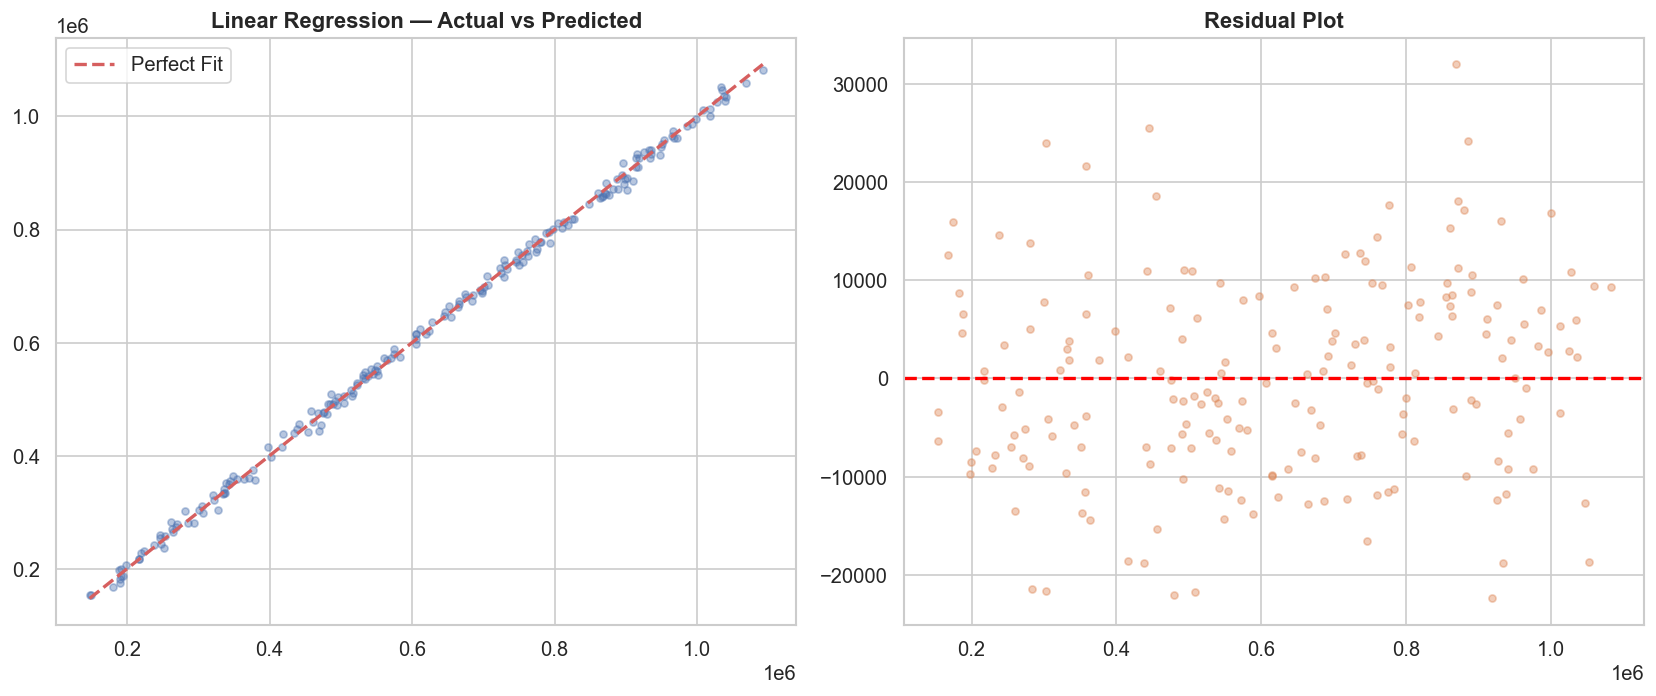

In [12]:
best_preds = next(r['Predictions'] for r in results if r['Model'] == best_name)
residuals  = y_test.values - best_preds
fig, axes  = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(y_test, best_preds, alpha=0.4, s=18, color='#4C72B0')
lo, hi = y_test.min(), y_test.max()
axes[0].plot([lo, hi], [lo, hi], 'r--', lw=2, label='Perfect Fit')
axes[0].set_title(f'{best_name} — Actual vs Predicted', fontweight='bold'); axes[0].legend()
axes[1].scatter(best_preds, residuals, alpha=0.4, s=18, color='#DD8452')
axes[1].axhline(0, color='red', lw=2, linestyle='--')
axes[1].set_title('Residual Plot', fontweight='bold')
plt.tight_layout(); plt.savefig('07_actual_vs_pred.png', bbox_inches='tight'); plt.show()

## Feature Importance

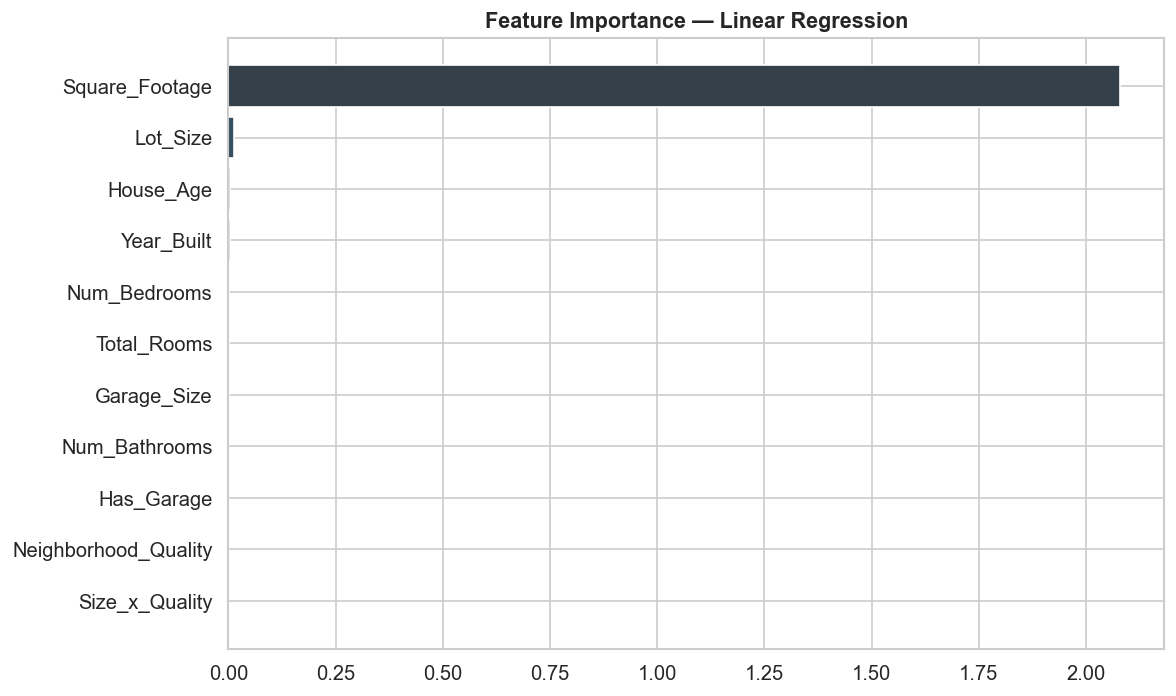

In [13]:
Xte_imp = X_test_s if best_scaled else X_test.values
if hasattr(best_obj, 'feature_importances_'):
    imp = best_obj.feature_importances_
else:
    pi  = permutation_importance(best_obj, Xte_imp, y_test, n_repeats=15, random_state=RANDOM_STATE)
    imp = pi.importances_mean
imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': np.abs(imp)}).sort_values('Importance')
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(imp_df['Feature'], imp_df['Importance'], color=sns.color_palette('Blues_d', len(imp_df)))
ax.set_title(f'Feature Importance — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('08_feature_importance.png', bbox_inches='tight'); plt.show()

## Save Model

In [16]:
os.makedirs('models', exist_ok=True)
joblib.dump(best_obj,      'models/best_model.pkl')
joblib.dump(scaler,        'models/scaler.pkl')
joblib.dump(feature_names, 'models/feature_names.pkl')
results_df.to_csv('models/model_comparison.csv', index=False)
print(' Model saved to models/')

 Model saved to models/


## Predict Function

In [15]:
def predict_price(square_footage, num_bedrooms, num_bathrooms,
                  year_built, lot_size, garage_size, neighborhood_quality):
    model = joblib.load('models/best_model.pkl')
    feats = joblib.load('models/feature_names.pkl')
    row   = pd.DataFrame([[
        square_footage, num_bedrooms, num_bathrooms, year_built, lot_size, garage_size,
        neighborhood_quality, 2024 - year_built, num_bedrooms + num_bathrooms,
        square_footage * neighborhood_quality, int(garage_size > 0)
    ]], columns=feats)
    return round(model.predict(row)[0], 2)

# Test it
price = predict_price(2500, 3, 2, 2000, 3.5, 1, 7)
print(f'Predicted Price: ₹{price:,.2f}')

Predicted Price: ₹629,068,973.36
